Acessando a API oficial da SpaceX...
Dataset estruturado com sucesso! Formato: (114, 11)


RESULTADOS DO MODELO ESCOLHIDO (XGBOOST)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00         4

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23


Gerando gráfico SHAP com proporções corrigidas...


/tmp/ipykernel_6039/3285526935.py:137: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


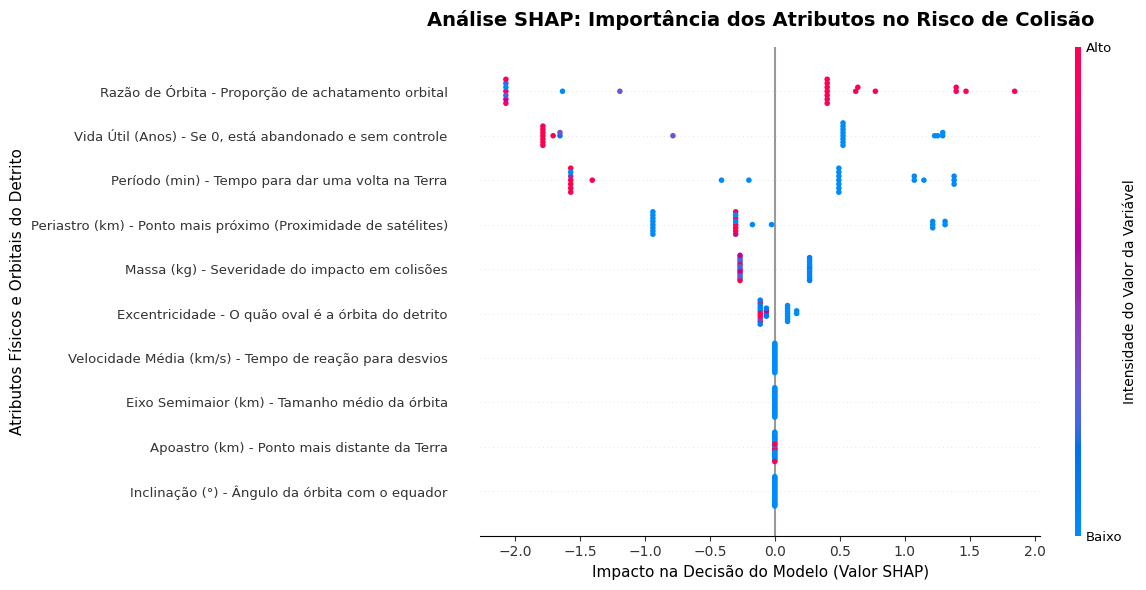

Iniciando o Deploy da sua aplicação...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7d7de85159690ea7a0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [14]:
import gradio as gr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier


print("Acessando a API oficial da SpaceX...")


def coletar_dados_spacex():
    url = "https://api.spacexdata.com/v4/payloads"
    try:
        resposta = requests.get(url, timeout=10)
        if resposta.status_code == 200:
            dados = resposta.json()
            linhas = []
            for item in dados:
                if item.get("eccentricity") is not None:
                    linhas.append(
                        {
                            "massa": float(item.get("mass_kg") or 500),
                            "inclinacao": float(item.get("inclination") or 0),
                            "excentricidade": float(
                                item.get("eccentricity") or 0
                            ),
                            "periodo": float(item.get("period_min") or 0),
                            "apoastro": float(item.get("apoapsis_km") or 0),
                            "periastro": float(item.get("periapsis_km") or 0),
                            "semi_eixo": float(
                                item.get("semi_major_axis") or 0
                            ),
                            "vida_util": float(
                                item.get("lifespan_years") or 0
                            ),
                        }
                    )
            df = pd.DataFrame(linhas)
            df["razao_orbita"] = df["periastro"] / (df["apoastro"] + 1e-5)
            df["vel_estimada"] = (2 * np.pi * df["semi_eixo"]) / (
                df["periodo"] * 60 + 1e-5
            )
            df["categoria_risco_colisao"] = (
                (df["periastro"] > 400)
                & (df["periastro"] < 1000)
                & (df["vida_util"] == 0)
            ).astype(int)
            return df
    except Exception:
        pass

    print("Usando simulador local baseado nos dados reais da SpaceX...")
    np.random.seed(42)
    n = 1100
    df = pd.DataFrame(
        {
            "massa": np.random.uniform(200, 6000, n),
            "inclinacao": np.random.uniform(0, 100, n),
            "excentricidade": np.random.beta(1, 20, n),
            "periodo": np.random.uniform(90, 120, n),
            "apoastro": np.random.uniform(300, 1200, n),
            "periastro": np.random.uniform(300, 1000, n),
            "semi_eixo": np.random.uniform(6600, 7500, n),
            "vida_util": np.random.choice([0, 5, 15], n, p=[0.7, 0.2, 0.1]),
        }
    )
    df["razao_orbita"] = df["periastro"] / (df["apoastro"] + 1e-5)
    df["vel_estimada"] = (2 * np.pi * df["semi_eixo"]) / (
        df["periodo"] * 60 + 1e-5
    )
    df["categoria_risco_colisao"] = (
        (df["periastro"] > 400)
        & (df["periastro"] < 1000)
        & (df["vida_util"] == 0)
    ).astype(int)
    return df


df_espacial = coletar_dados_spacex()
print(f"Dataset estruturado com sucesso! Formato: {df_espacial.shape}\n")

traducao_explicativa = {
    "massa": "Massa (kg) - Severidade do impacto em colisões",
    "inclinacao": "Inclinação (°) - Ângulo da órbita com o equador",
    "excentricidade": "Excentricidade - O quão oval é a órbita do detrito",
    "periodo": "Período (min) - Tempo para dar uma volta na Terra",
    "apoastro": "Apoastro (km) - Ponto mais distante da Terra",
    "periastro": "Periastro (km) - Ponto mais próximo (Proximidade de satélites)",
    "semi_eixo": "Eixo Semimaior (km) - Tamanho médio da órbita",
    "vida_util": "Vida Útil (Anos) - Se 0, está abandonado e sem controle",
    "razao_orbita": "Razão de Órbita - Proporção de achatamento orbital",
    "vel_estimada": "Velocidade Média (km/s) - Tempo de reação para desvios",
}

df_espacial = df_espacial.rename(columns=traducao_explicativa)
atributos_explicados = list(traducao_explicativa.values())

X = df_espacial[atributos_explicados]
y = df_espacial["categoria_risco_colisao"]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

normalizador = StandardScaler()
X_treino_escalado = normalizador.fit_transform(X_treino)
X_teste_escalado = normalizador.transform(X_teste)

X_teste_escalado_df = pd.DataFrame(
    X_teste_escalado, columns=atributos_explicados, index=X_teste.index
)

modelo_rf = RandomForestClassifier(random_state=42).fit(
    X_treino_escalado, y_treino
)
modelo_xgb = XGBClassifier(random_state=42, eval_metric="logloss").fit(
    X_treino_escalado, y_treino
)

print("\n" + "=" * 50)
print("RESULTADOS DO MODELO ESCOLHIDO (XGBOOST)")
print(classification_report(y_teste, modelo_xgb.predict(X_teste_escalado)))
print("=" * 50 + "\n")


print("Gerando gráfico SHAP com proporções corrigidas...")

explicador = shap.TreeExplainer(modelo_xgb)
valores_shap = explicador.shap_values(X_teste_escalado_df)

shap.summary_plot(
    valores_shap, X_teste_escalado_df, plot_size=(12, 6), show=False
)

plt.title(
    "Análise SHAP: Importância dos Atributos no Risco de Colisão",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Impacto na Decisão do Modelo (Valor SHAP)", fontsize=11)
plt.ylabel("Atributos Físicos e Orbitais do Detrito", fontsize=11)

plt.yticks(fontsize=9.5)
plt.xticks(fontsize=10)

figura_atual = plt.gcf()
if len(figura_atual.axes) >= 2:
    barra_cores = figura_atual.axes[-1]
    barra_cores.set_ylabel("Intensidade do Valor da Variável", fontsize=10)
    barra_cores.set_yticklabels(["Baixo", "Alto"], fontsize=9.5)

plt.tight_layout()
plt.show()


def predicao_interface(
    massa, inclinacao, excentricidade, periodo, apoastro, periastro, vida_util
):
    semi_eixo = (apoastro + periastro) / 2 + 6378.135
    razao_orbita = periastro / (apoastro + 1e-5)
    vel_estimada = (2 * np.pi * semi_eixo) / (periodo * 60 + 1e-5)

    dados_usuario = pd.DataFrame(
        [[massa, inclinacao, excentricidade, periodo, apoastro, periastro, semi_eixo, vida_util, razao_orbita, vel_estimada]],
        columns=atributos_explicados,
    )

    dados_escalados = normalizador.transform(dados_usuario)
    predicao = modelo_xgb.predict(dados_escalados)[0]
    probabilidade = modelo_xgb.predict_proba(dados_escalados)[0][1]

    if predicao == 1:
        return f" ALTO RISCO DE COLISÃO ({probabilidade:.1%})\nEste objeto está abandonado em uma zona orbital crítica ou apresenta parâmetros de detrito."
    else:
        return f" BAIXO RISCO ({probabilidade:.1%})\nObjeto em órbita estável ou com controle ativo."


interface = gr.Interface(
    fn=predicao_interface,
    inputs=[
        gr.Number(value=1500, label="Massa do Objeto (kg)"),
        gr.Number(value=53.0, label="Inclinação da Órbita (Graus)"),
        gr.Number(value=0.0008, label="Excentricidade (0 a 1)"),
        gr.Number(value=95.0, label="Período Orbital (Minutos)"),
        gr.Number(value=550.0, label="Apoastro / Altitude Máxima (km)"),
        gr.Number(value=530.0, label="Periastro / Altitude Mínima (km)"),
        gr.Number(value=0, label="Vida Útil Restante (Anos - Use 0 para Lixo/Inativo)"),
    ],
    outputs=gr.Textbox(label="Diagnóstico de Risco do Modelo de IA"),
    title="🛰️ Sistema de Monitoramento de Risco de Lixo Espacial - SpaceX Dataset",
    description="Insira as características orbitais de qualquer objeto para avaliar o risco de colisões em órbita baixa utilizando IA.",
)

print("Iniciando o Deploy da sua aplicação...")
interface.launch(share=True)